In [1]:
from common import *
import matplotlib.pyplot as plt
from rdkit import Chem
from rdkit.Chem import DataStructs, Descriptors
from IPython.display import Image, display

from IPDiff.utils import reconstruct
import IPDiff.utils.transforms as trans

/home/adrianchen/miniconda3/envs/protein-docking/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
root_dir = '/home/adrianchen/IPDiff'
protein_paths = [
    os.path.join(root_dir, 'pockets/7upg_pocket1.pdb'), 
    os.path.join(root_dir, 'pockets/7upg_pocket1.pdb'),
    os.path.join(root_dir, 'pockets/7upg_pocket1_2layer.pdb'),
    os.path.join(root_dir, 'pockets/7upg_pocket1_3layer.pdb'),
]
result_files = [
    os.path.join(root_dir, 'sampled_results/7upg_pocket1/sample_2025-03-20_22-57-38_079.pt'), 
    os.path.join(root_dir, 'sampled_results/7upg_pocket1/sample_2025-04-11_01-32-22_015.pt'), 
    os.path.join(root_dir, 'sampled_results/7upg_pocket1_2layer/sample_2025-04-05_14-12-05_083.pt'),
    os.path.join(root_dir, 'sampled_results/7upg_pocket1_3layer/sample_2025-04-05_14-12-21_083.pt'),
]
annotations = [
    "5layer", "5layer_10-40", "2layer", "3layer"
]

num_samples = 1000
pred_ligand_pos_ls, pred_ligand_v_ls = [], []
for result_file, annotation in zip(result_files, annotations):
    result = torch.load(result_file)
    pred_ligand_pos, pred_ligand_v = [], []
    for pos, v in zip(result['pred_ligand_pos'], result['pred_ligand_v']):
        pred_ligand_pos += pos
        pred_ligand_v += v
    
    print(f'{annotation} has {len(pred_ligand_pos)} generated ligands')
    num_samples = min(num_samples, len(pred_ligand_pos))
    pred_ligand_pos_ls.append(pred_ligand_pos)
    pred_ligand_v_ls.append(pred_ligand_v)

5layer has 2000 generated ligands
5layer_10-40 has 400 generated ligands
2layer has 1000 generated ligands
3layer has 1000 generated ligands


In [ ]:
mol_weights_ls, logps_ls = [], []
for pred_ligand_pos, pred_ligand_v, annotation in zip(pred_ligand_pos_ls, pred_ligand_v_ls, annotations):
    mol_weights, logps = [], []
    num_reconstruct_errors, num_broken_smiles = 0, 0
    for sample_idx, (pos, v) in enumerate(zip(pred_ligand_pos[:num_samples], pred_ligand_v[:num_samples])):
        pred_atom_type = trans.get_atomic_number_from_index(v, mode='add_aromatic')
        try:
            pred_aromatic = trans.is_aromatic_from_index(v, mode='add_aromatic')
            mol = reconstruct.reconstruct_from_generated(pos, pred_atom_type, pred_aromatic)
            smiles = Chem.MolToSmiles(mol)
        except reconstruct.MolReconsError:
            num_reconstruct_errors += 1
            continue
        
        if '.' in smiles:
            num_broken_smiles += 1
            continue
        
        mol_weights.append(Descriptors.MolWt(mol))
        logps.append(Descriptors.MolLogP(mol))
        
    print(f'{annotation} has {len(mol_weights)} valid generated ligands within {num_samples} samples, \
        {num_reconstruct_errors} reconstruction errors and {num_broken_smiles} invalid smiles. ')
    mol_weights_ls.append(mol_weights)
    logps_ls.append(logps)

[09:12:17] Explicit valence for atom # 13 O, 3, is greater than permitted
[09:12:17] Explicit valence for atom # 3 O, 3, is greater than permitted
[09:12:17] Explicit valence for atom # 28 O, 3, is greater than permitted
[09:12:17] Explicit valence for atom # 0 O, 3, is greater than permitted
[09:12:18] Explicit valence for atom # 14 O, 3, is greater than permitted
[09:12:18] Explicit valence for atom # 32 O, 3, is greater than permitted
[09:12:18] Explicit valence for atom # 29 O, 3, is greater than permitted
[09:12:19] Explicit valence for atom # 13 O, 3, is greater than permitted
[09:12:19] Explicit valence for atom # 23 O, 3, is greater than permitted
[09:12:19] Explicit valence for atom # 5 O, 3, is greater than permitted


5layer has 338 valid generated ligands within 400 samples,         10 reconstruction errors and 52 invalid smiles. 


[09:12:21] Explicit valence for atom # 21 O, 3, is greater than permitted
[09:12:21] Explicit valence for atom # 13 O, 3, is greater than permitted
[09:12:22] Explicit valence for atom # 5 O, 3, is greater than permitted
[09:12:22] Explicit valence for atom # 3 O, 3, is greater than permitted


5layer_10-40 has 342 valid generated ligands within 400 samples,         4 reconstruction errors and 54 invalid smiles. 


[09:12:24] Explicit valence for atom # 18 F, 2, is greater than permitted
[09:12:26] Explicit valence for atom # 26 O, 3, is greater than permitted


2layer has 387 valid generated ligands within 400 samples,         2 reconstruction errors and 11 invalid smiles. 


[09:12:27] Explicit valence for atom # 21 O, 3, is greater than permitted
*** Open Babel Warning  in PerceiveBondOrders
  Failed to kekulize aromatic bonds in OBMol::PerceiveBondOrders

[09:12:29] Explicit valence for atom # 23 Cl, 2, is greater than permitted


3layer has 377 valid generated ligands within 400 samples,         2 reconstruction errors and 21 invalid smiles. 


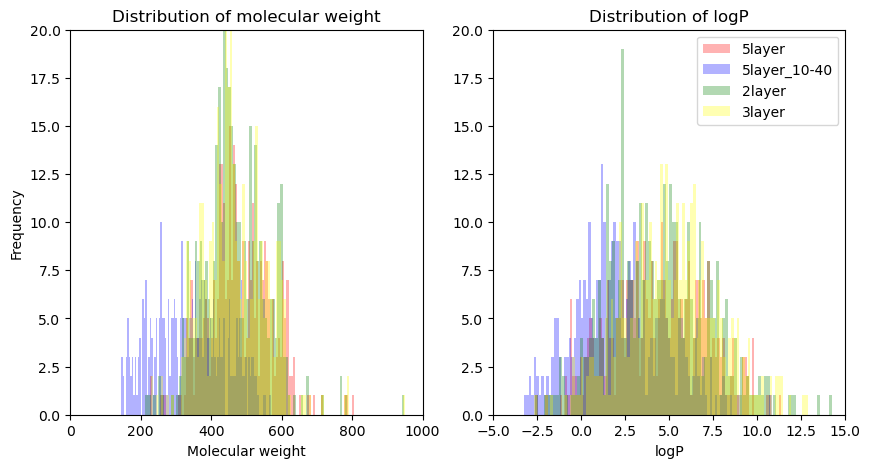

In [10]:
show_indices = [0, 1, 2, 3]
colors = ['red', 'blue', 'green', 'yellow']

plt.figure(figsize=(10, 5)) 
plt.subplot(1, 2, 1)
plt.title('Distribution of molecular weight')
plt.xlabel('Molecular weight')
plt.ylabel('Frequency')
plt.xlim(0, 1000)
plt.ylim(0, 20)
for idx, (mol_weights, annotation, color) in enumerate(zip(mol_weights_ls, annotations, colors)):
    if idx not in show_indices:
        continue
    plt.hist(mol_weights, bins=100, label=annotation, alpha=0.3, color=color)

plt.subplot(1, 2, 2)
plt.title('Distribution of logP')
plt.xlabel('logP')
plt.xlim(-5, 15)
plt.ylim(0, 20)
for idx, (logps, annotation, color) in enumerate(zip(logps_ls, annotations, colors)):
    if idx not in show_indices:
        continue
    plt.hist(logps, bins=100, label=annotation, alpha=0.3, color=color)

plt.legend()
plt.show()